### 🤖 Implement ReAct with LangGraph - What is ReAct?

ReAct (Reasoning + Act) is a framework where an LLM:

- Reasons step-by-step (e.g., decomposes questions, make decisions)
- Acts by calling tools like search, calculators or retrievers

This makes it perfect for Agentic RAG: ✅ Think -> Retriever -> Observe -> Reflect -> Final Answer

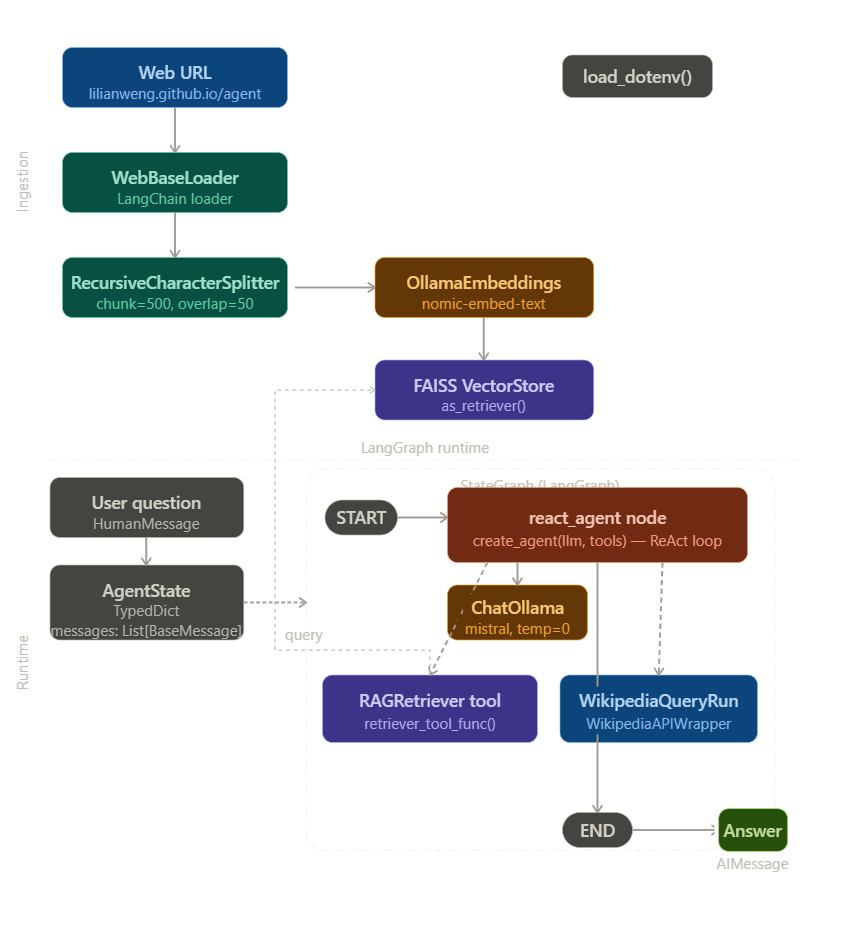

In [1]:
# ------------------------------------------------------------
# 1. Document Preprocessing, Text Splitting, Embedding and Vector Store
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
import os
from dotenv import load_dotenv

load_dotenv()

# Load the content
docs = WebBaseLoader('https://lilianweng.github.io/posts/2023-06-23-agent/').load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')
vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from langchain_ollama import ChatOllama

# LLM
llm = ChatOllama(model='mistral', temperature=0)

In [3]:
def retriever_tool_func(query: str) -> str:
    print('📚 Using RAG Retriever Tool')
    docs = retriever.invoke(query)
    return '\n\n'.join([doc.page_content for doc in docs])

In [4]:
from langchain_classic.agents import Tool

# Creating Tool
retriever_tool = Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info.",
    func=retriever_tool_func
)

In [5]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

# Wikipedia Tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

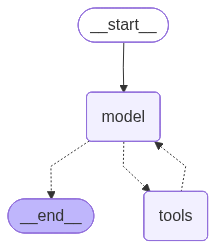

In [6]:
# ------------------------------------------------------------
# 2. Define the Agent Node
# ------------------------------------------------------------

from langchain.agents import create_agent

tools = [retriever_tool, wiki_tool]

# Create the native Langgraph react agent
react_node = create_agent(llm, tools)
react_node

In [7]:
# ------------------------------------------------------------
# 3. LangGraph Agent State
# ------------------------------------------------------------

from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

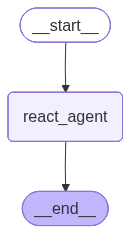

In [8]:
# ------------------------------------------------------------
# 4. Build LangGraph Graph
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

builder.add_node('react_agent', react_node)
builder.set_entry_point('react_agent')
builder.add_edge('react_agent', END)

graph = builder.compile()
graph


In [12]:
# ------------------------------------------------------------
# 5. Run the Agentic RAG
# ------------------------------------------------------------

if __name__ == '__main__':
    user_question = 'What is an agent loop and how does Wikipedia describe autonomous agents?'
    state = {'messages': [HumanMessage(content=user_question)]}
    result = graph.invoke(state)
    
    print('\n✅ Final Answer:\n', result['messages'][-1].content)

📚 Using RAG Retriever Tool

✅ Final Answer:
  An agent loop refers to the continuous cycle of perception, reasoning, and action taken by an autonomous agent in order to achieve its goals. The agent perceives its environment, processes the information it receives, makes decisions based on its objectives, and then takes actions to affect the environment accordingly. This process is repeated until the agent achieves its goal or a new goal is set.

Wikipedia describes autonomous agents as artificial intelligence systems that can perform complex tasks independently. These agents are designed to operate in dynamic environments and make decisions based on their objectives, often using machine learning and knowledge acquisition to improve their performance over time. Autonomous agents can be equipped with dynamic memory and self-reflection capabilities to enhance their reasoning skills, and they may also call external APIs for additional information that is not included in the model weights. T